In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Loading the data 
ratings = pd.read_csv('ml-100k/ml-100k/u.data',sep='\t',names=['userId','movieId','rating','timestamp'])
movies = pd.read_csv('ml-100k/ml-100k/u.item', sep='|', encoding='latin-1',
                      names=['movieId', 'title','release date' ,'video release date',
              'IMDb URL','unknown',' Action' , 'Adventure' , 'Animation',
              'Children' , 'Comedy' , 'Crime', 'Documentary' , 'Drama' , 'Fantasy' ,
              'Film-Noir' , 'Horror' , 'Musical' , 'Mystery ', 'Romance' , 'Sci-Fi' ,
              'Thriller' ,'War' ,'Western'])
print("Ratings shape:",ratings.shape)
print("Movies shape:",movies.shape)
print()
print(ratings.head(10))
print()
print(movies.head())
print()
print(ratings.info)
print(movies.info)



Ratings shape: (100000, 4)
Movies shape: (1682, 24)

   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596
5     298      474       4  884182806
6     115      265       2  881171488
7     253      465       5  891628467
8     305      451       3  886324817
9       6       86       3  883603013

   movieId              title release date  video release date  \
0        1   Toy Story (1995)  01-Jan-1995                 NaN   
1        2   GoldenEye (1995)  01-Jan-1995                 NaN   
2        3  Four Rooms (1995)  01-Jan-1995                 NaN   
3        4  Get Shorty (1995)  01-Jan-1995                 NaN   
4        5     Copycat (1995)  01-Jan-1995                 NaN   

                                            IMDb URL  unknown   Action  \
0  http://us.imdb.com/M/title-exact?Toy%20Story%2...     

In [2]:
rating_count = ratings.groupby('movieId')['rating'].count()
print("Rating count\n",rating_count)
print()
print("Most rated movie id is :",rating_count.idxmax(),"with",rating_count.max(),"times rated")
print()
print("Least rated movie id is :",rating_count.idxmin(),"with",rating_count.min(),"times rated")

Rating count
 movieId
1       452
2       131
3        90
4       209
5        86
       ... 
1678      1
1679      1
1680      1
1681      1
1682      1
Name: rating, Length: 1682, dtype: int64

Most rated movie id is : 50 with 583 times rated

Least rated movie id is : 599 with 1 times rated


In [3]:
avg_rating = ratings.groupby('movieId')['rating'].mean()
print(avg_rating)

movieId
1       3.878319
2       3.206107
3       3.033333
4       3.550239
5       3.302326
          ...   
1678    1.000000
1679    3.000000
1680    2.000000
1681    3.000000
1682    3.000000
Name: rating, Length: 1682, dtype: float64


In [4]:
movie_stats = pd.DataFrame({
    "rating" : avg_rating,
    "count" : rating_count
}).join(movies.set_index('movieId')['title'])
print(movie_stats)

           rating  count                                      title
movieId                                                            
1        3.878319    452                           Toy Story (1995)
2        3.206107    131                           GoldenEye (1995)
3        3.033333     90                          Four Rooms (1995)
4        3.550239    209                          Get Shorty (1995)
5        3.302326     86                             Copycat (1995)
...           ...    ...                                        ...
1678     1.000000      1                          Mat' i syn (1997)
1679     3.000000      1                           B. Monkey (1998)
1680     2.000000      1                       Sliding Doors (1998)
1681     3.000000      1                        You So Crazy (1994)
1682     3.000000      1  Scream of Stone (Schrei aus Stein) (1991)

[1682 rows x 3 columns]


In [5]:
print("Top 20 most rated movies with their average count and rating :")
print()
print(movie_stats.nlargest(20,'count'))

Top 20 most rated movies with their average count and rating :

           rating  count                             title
movieId                                                   
50       4.358491    583                  Star Wars (1977)
258      3.803536    509                    Contact (1997)
100      4.155512    508                      Fargo (1996)
181      4.007890    507         Return of the Jedi (1983)
294      3.156701    485                  Liar Liar (1997)
286      3.656965    481       English Patient, The (1996)
288      3.441423    478                     Scream (1996)
1        3.878319    452                  Toy Story (1995)
300      3.631090    431              Air Force One (1997)
121      3.438228    429     Independence Day (ID4) (1996)
174      4.252381    420    Raiders of the Lost Ark (1981)
127      4.283293    413             Godfather, The (1972)
56       4.060914    394               Pulp Fiction (1994)
7        3.798469    392             Twelve Monkeys

In [6]:
#Removing the movie containing movies rated 1 time
#movie_stats = movie_stats[movie_stats['count'] != 1]
print((movie_stats['count']== 1).sum())

141


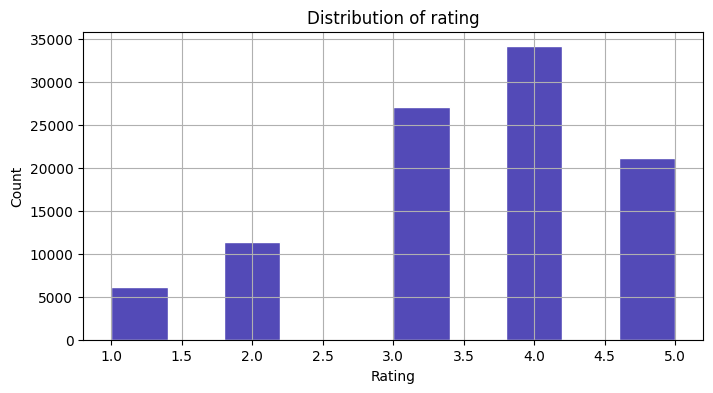

In [7]:
# Plot rating distribution
plt.figure(figsize=(8,4))
ratings['rating'].hist(bins=10,color='#534AB7',edgecolor='white')
plt.title('Distribution of rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [8]:
#Users are generous raters .The most common rating is 4 out of 5 (~34,000 times). People rarely give 1s. This means your dataset is positively skewed — most ratings cluster between 3 and 5

In [9]:
print(movies.columns.tolist())
print(movies.head())

['movieId', 'title', 'release date', 'video release date', 'IMDb URL', 'unknown', ' Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery ', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
   movieId              title release date  video release date  \
0        1   Toy Story (1995)  01-Jan-1995                 NaN   
1        2   GoldenEye (1995)  01-Jan-1995                 NaN   
2        3  Four Rooms (1995)  01-Jan-1995                 NaN   
3        4  Get Shorty (1995)  01-Jan-1995                 NaN   
4        5     Copycat (1995)  01-Jan-1995                 NaN   

                                            IMDb URL  unknown   Action  \
0  http://us.imdb.com/M/title-exact?Toy%20Story%2...        0        0   
1  http://us.imdb.com/M/title-exact?GoldenEye%20(...        0        1   
2  http://us.imdb.com/M/title-exact?Four%20Rooms%...        0        0   
3  http://us.imdb.com/M/t

In [10]:
genre_names =['unknown','Action','Adventure','Animation','Childrens',
               'Comedy','Crime','Documentary','Drama','Fantasy',
               'FilmNoir','Horror','Musical','Mystery','Romance',
               'SciFi','Thriller','War','Western']
movies = pd.read_csv('ml-100k/ml-100k/u.item',sep='|',encoding='latin-1',names=['movieId','title','release date','video date',
                             'imdb_url']+genre_names,usecols=['movieId','title']+genre_names)
print(movies.head())

   movieId              title  unknown  Action  Adventure  Animation  \
0        1   Toy Story (1995)        0       0          0          1   
1        2   GoldenEye (1995)        0       1          1          0   
2        3  Four Rooms (1995)        0       0          0          0   
3        4  Get Shorty (1995)        0       1          0          0   
4        5     Copycat (1995)        0       0          0          0   

   Childrens  Comedy  Crime  Documentary  ...  Fantasy  FilmNoir  Horror  \
0          1       1      0            0  ...        0         0       0   
1          0       0      0            0  ...        0         0       0   
2          0       0      0            0  ...        0         0       0   
3          0       1      0            0  ...        0         0       0   
4          0       0      1            0  ...        0         0       0   

   Musical  Mystery  Romance  SciFi  Thriller  War  Western  
0        0        0        0      0         0   

In [11]:
genre_count = movies[genre_names].sum().sort_values(ascending=False)
print(genre_count)


Drama          725
Comedy         505
Action         251
Thriller       251
Romance        247
Adventure      135
Childrens      122
Crime          109
SciFi          101
Horror          92
War             71
Mystery         61
Musical         56
Documentary     50
Animation       42
Western         27
FilmNoir        24
Fantasy         22
unknown          2
dtype: int64


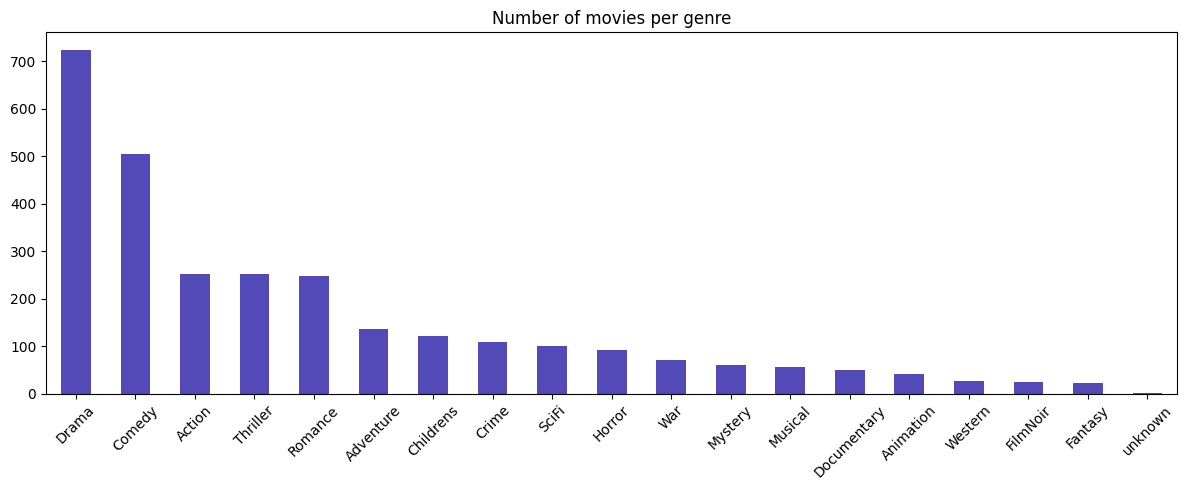

In [12]:
genre_count.plot(kind='bar', figsize=(12,5), color='#534AB7')
plt.title('Number of movies per genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
merged = movies.merge(ratings,on='movieId')
print(merged.head())


   movieId             title  unknown  Action  Adventure  Animation  \
0        1  Toy Story (1995)        0       0          0          1   
1        1  Toy Story (1995)        0       0          0          1   
2        1  Toy Story (1995)        0       0          0          1   
3        1  Toy Story (1995)        0       0          0          1   
4        1  Toy Story (1995)        0       0          0          1   

   Childrens  Comedy  Crime  Documentary  ...  Musical  Mystery  Romance  \
0          1       1      0            0  ...        0        0        0   
1          1       1      0            0  ...        0        0        0   
2          1       1      0            0  ...        0        0        0   
3          1       1      0            0  ...        0        0        0   
4          1       1      0            0  ...        0        0        0   

   SciFi  Thriller  War  Western  userId  rating  timestamp  
0      0         0    0        0     308       4  8877

In [14]:
#genre_rating = merged.groupby('genre_names')['rating'].mean().sort_values(ascending=False)
genre_ratings = {}
for genre in genre_names:
    #Get movieId that belong to the genre
    genre_movies = movies[movies[genre]==1]['movieId']
    #Get all ratings for those movies
    avg = merged[merged['movieId'].isin(genre_movies)]['rating'].mean()
    genre_ratings[genre] =round(avg,2)
#caonvert to series
genre_ratings = pd.Series(genre_ratings).sort_values(ascending=False)
print(genre_ratings)

FilmNoir       3.92
War            3.82
Drama          3.69
Documentary    3.67
Mystery        3.64
Crime          3.63
Romance        3.62
Western        3.61
Animation      3.58
SciFi          3.56
Musical        3.52
Thriller       3.51
Adventure      3.50
Action         3.48
Comedy         3.39
Childrens      3.35
Horror         3.29
Fantasy        3.22
unknown        3.20
dtype: float64


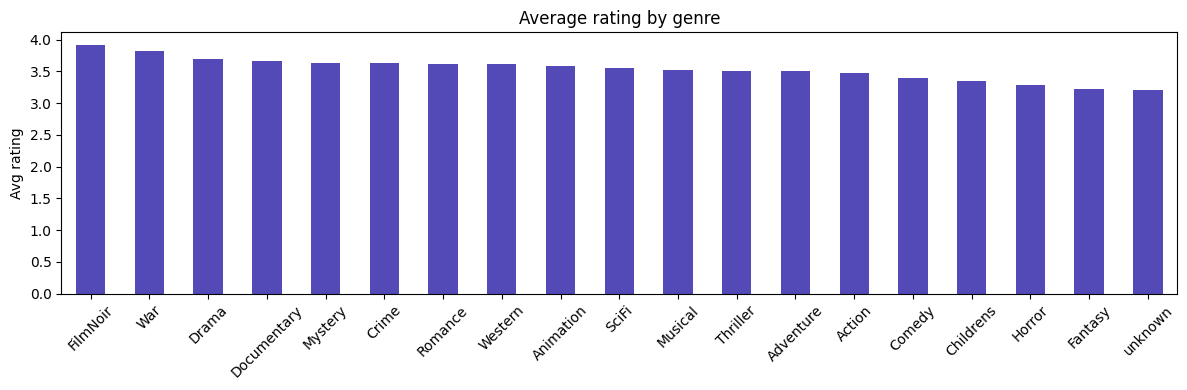

In [15]:
genre_ratings.plot(kind='bar',figsize=(12,4),color='#534AB7')
plt.title('Average rating by genre')
plt.ylabel('Avg rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
user_item = merged.pivot_table(index='userId',columns='title',values='rating')
print("Matrix shape",user_item.shape)
print()
print(user_item.head())

Matrix shape (943, 1664)

title   'Til There Was You (1997)  1-900 (1994)  101 Dalmatians (1996)  \
userId                                                                   
1                             NaN           NaN                    2.0   
2                             NaN           NaN                    NaN   
3                             NaN           NaN                    NaN   
4                             NaN           NaN                    NaN   
5                             NaN           NaN                    2.0   

title   12 Angry Men (1957)  187 (1997)  2 Days in the Valley (1996)  \
userId                                                                 
1                       5.0         NaN                          NaN   
2                       NaN         NaN                          NaN   
3                       NaN         2.0                          NaN   
4                       NaN         NaN                          NaN   
5                      

In [17]:
#Calculate sparsity
total_cells = user_item.shape[0]*user_item.shape[1]
filled_cells = user_item.notna().sum().sum()
sparsity = 1 - (filled_cells/total_cells)
print(f"Total cells:  {total_cells:,}")
print(f"Filled cells :{filled_cells:,}")
print(f"Sparsity: {sparsity:.1%}")

Total cells:  1,569,152
Filled cells :99,693
Sparsity: 93.6%


In [18]:
#Filtering to reduce sparsity
movie_counts = ratings.groupby('movieId')['rating'].count()
user_counts = ratings.groupby('userId')['rating'].count()

good_movies = movie_counts[movie_counts >= 50].index
good_users = user_counts[user_counts >= 20].index

filtered = merged[merged['movieId'].isin(good_movies)&merged['userId'].isin(good_users)]

user_item_filtered = filtered.pivot_table(index='userId',columns='title',values='rating')
print("Filtered matrix shape :",user_item_filtered.shape)

#Checking sparsity of filtered matrix
total_filtered = filtered.shape[0]*filtered.shape[1]
filled_filterd = filtered.notna().sum().sum()
filtered_sparsity = 1-(filled_filterd/total_filtered)
print(f"Sparsity:{filtered_sparsity:.1%}")

#Saving filtered
user_item_filtered.to_csv('user_item_matrix.csv')
print(user_item_filtered.head())

Filtered matrix shape : (943, 601)
Sparsity:0.0%
title   101 Dalmatians (1996)  12 Angry Men (1957)  \
userId                                               
1                         2.0                  5.0   
2                         NaN                  NaN   
3                         NaN                  NaN   
4                         NaN                  NaN   
5                         2.0                  NaN   

title   2 Days in the Valley (1996)  20,000 Leagues Under the Sea (1954)  \
userId                                                                     
1                               NaN                                  3.0   
2                               NaN                                  NaN   
3                               NaN                                  NaN   
4                               NaN                                  NaN   
5                               NaN                                  NaN   

title   2001: A Space Odyssey (1968)  3

In [19]:
#Filling na with 0
matrix = user_item_filtered. fillna(0)
print(matrix)

title   101 Dalmatians (1996)  12 Angry Men (1957)  \
userId                                               
1                         2.0                  5.0   
2                         0.0                  0.0   
3                         0.0                  0.0   
4                         0.0                  0.0   
5                         2.0                  0.0   
...                       ...                  ...   
939                       0.0                  0.0   
940                       0.0                  0.0   
941                       0.0                  0.0   
942                       0.0                  0.0   
943                       0.0                  0.0   

title   2 Days in the Valley (1996)  20,000 Leagues Under the Sea (1954)  \
userId                                                                     
1                               0.0                                  3.0   
2                               0.0                                  

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

#Computing movie-movie similarity
#Transpose so movies are rows and user are columns
#Cosine similarity always compares rows to rows
movie_similarity = cosine_similarity(matrix.T)

#Wrap in a dataframe 
sim_df = pd.DataFrame(
    movie_similarity,
    index=user_item_filtered.columns,
    columns=user_item_filtered.columns
)    

def get_similar_movies(title,n=5):
    if title not in sim_df.columns:
        return print(f"Movies {title} not found")
    #Get similarity scores for this movie
    scores = sim_df[title].sort_values(ascending = False)
    #Skip the movie itself
    return scores.iloc[1:n+1]

#Testing
print(get_similar_movies("Toy Story (1995)"))
print()
print(get_similar_movies("The Dark Knight (2008)"))

title
Star Wars (1977)                 0.734572
Return of the Jedi (1983)        0.699925
Independence Day (ID4) (1996)    0.689786
Rock, The (1996)                 0.664555
Mission: Impossible (1996)       0.641322
Name: Toy Story (1995), dtype: float64

Movies The Dark Knight (2008) not found
None


In [25]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy
import pandas as pd

# Loading existing ratings DataFrame
ratings =  pd.read_csv('ml-100k/ml-100k/u.data',sep='\t',names=['userId','movieId','rating','timestamp'])

#  title lookup dictionary
movies = pd.read_csv('ml-100k/ml-100k/u.item', sep='|', encoding='latin-1',
                      names=['movieId','title'] + [f'col_{i}' for i in range(22)],
                      usecols=['movieId','title'])

id_to_title = dict(zip(movies['movieId'], movies['title']))
# Telling Surprise the rating scale is 1 to 5
reader = Reader(rating_scale = (1,5))

#Loading in surprise format from pandas df
data = Dataset.load_from_df(ratings[['userId','movieId','rating']],reader)

# trainset = data.build_full_trainset()
# print("Number of users:", trainset.n_users)
# print("Number of items:", trainset.n_items)
# print("Number of ratings:", trainset.n_ratings)


In [26]:
#Splitting 80% train, 20% test
trainset,testset =train_test_split(data,test_size=0.2,random_state=42)

#Training SVD
model = SVD(random_state=42)
model.fit(trainset)
print("Model trained!")

sample_rating = ratings[ratings['userId']==1].head(3)
print("Predictions for user 1:")
print("-" * 45)

for _,row in sample_rating.iterrows():
    uid = row['userId']
    iid = row['movieId']
    actual = row['rating']

    pred = model.predict(uid=uid,iid=iid)
    title = id_to_title.get(iid,'Unknown')

    print(f"Movie : {title}")
    print(f"Actual : {actual} stars")
    print(f"Predicted :{pred.est:.2f}")

Model trained!
Predictions for user 1:
---------------------------------------------
Movie : Three Colors: White (1994)
Actual : 4 stars
Predicted :3.82
Movie : Grand Day Out, A (1992)
Actual : 3 stars
Predicted :4.09
Movie : Desperado (1995)
Actual : 4 stars
Predicted :3.66


In [28]:
print("More predictions:")
print("-" * 45)
for user_id in [2, 3, 4, 5]:
    sample = ratings[ratings['userId'] == user_id].iloc[0]
    pred   = model.predict(uid=sample['userId'],
                                 iid=sample['movieId'])
    title  = id_to_title.get(sample['movieId'], 'Unknown')

    print(f"User {user_id} → {title}")
    print(f"  Actual: {sample['rating']} | Predicted: {pred.est:.2f}")
    print()

More predictions:
---------------------------------------------
User 2 → Rosewood (1997)
  Actual: 4 | Predicted: 3.80

User 3 → How to Be a Player (1997)
  Actual: 1 | Predicted: 1.99

User 4 → Mimic (1997)
  Actual: 3 | Predicted: 3.51

User 5 → GoldenEye (1995)
  Actual: 3 | Predicted: 2.84

